In [2]:
import ee
ee.Authenticate()

In [3]:
ee.Initialize(project='extreme-flame-286107')

jaipur = ee.Geometry.Point([75.7873, 26.9124]).buffer(15000)

collection = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(jaipur) \
    .filterDate('2023-04-01', '2023-06-30') \
    .filter(ee.Filter.lt('CLOUD_COVER', 10))

print(f"Images found: {collection.size().getInfo()}")
print("GEE working on Colab!")

Images found: 5
GEE working on Colab!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get best image
image = collection.sort('CLOUD_COVER').first()
date = image.date().format('YYYY-MM-dd').getInfo()
cloud = image.get('CLOUD_COVER').getInfo()
print(f"Best image: {date} — cloud cover: {cloud:.1f}%")

# Compute LST
lst_jaipur = image.select('ST_B10') \
    .multiply(0.00341802) \
    .add(149.0) \
    .subtract(273.15) \
    .rename('LST_Celsius') \
    .clip(jaipur)

# Compute NDVI
def apply_scale_factors(image):
    optical = image.select('SR_B.') \
                   .multiply(0.0000275) \
                   .add(-0.2)
    return image.addBands(optical, None, True)

image_scaled = apply_scale_factors(image)
ndvi = image_scaled.normalizedDifference(['SR_B5', 'SR_B4']) \
                   .rename('NDVI') \
                   .clip(jaipur)

# Get stats
stats = lst_jaipur.reduceRegion(
    reducer=ee.Reducer.min()
        .combine(ee.Reducer.max(), '', True)
        .combine(ee.Reducer.mean(), '', True),
    geometry=jaipur,
    scale=30,
    maxPixels=1e9
).getInfo()

print(f"\nJaipur LST — {date}")
print(f"Min:  {stats['LST_Celsius_min']:.1f}°C")
print(f"Max:  {stats['LST_Celsius_max']:.1f}°C")
print(f"Mean: {stats['LST_Celsius_mean']:.1f}°C")

Best image: 2023-06-01 — cloud cover: 0.5%

Jaipur LST — 2023-06-01
Min:  26.2°C
Max:  43.4°C
Mean: 35.9°C


Pixels sampled: 151
Real LST-NDVI correlation: -0.451
LST range: 31.6 — 40.3°C
NDVI range: 0.129 — 0.652


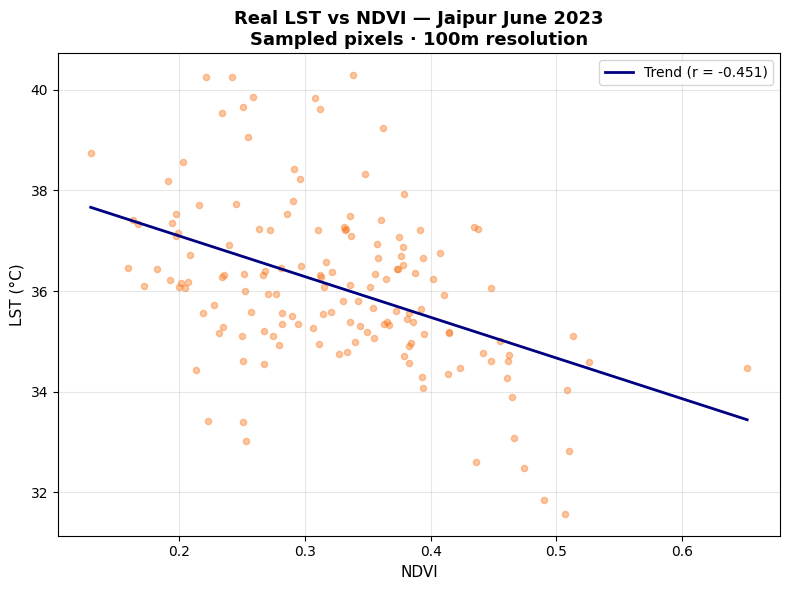

Correlation: -0.451


In [5]:
# Sample real pixels and compute correlation
combined = lst_jaipur.addBands(ndvi)

samples = combined.sample(
    region=jaipur,
    scale=100,
    numPixels=500,
    seed=42
)

sample_list = samples.getInfo()['features']
print(f"Pixels sampled: {len(sample_list)}")

# Build dataframe
lst_vals  = [f['properties']['LST_Celsius'] for f in sample_list]
ndvi_vals = [f['properties']['NDVI'] for f in sample_list]

df_real = pd.DataFrame({'lst': lst_vals, 'ndvi': ndvi_vals})

# Clean outliers
df_real = df_real[
    (df_real['lst'] > 20) &
    (df_real['lst'] < 55) &
    (df_real['ndvi'] > -0.1) &
    (df_real['ndvi'] < 1.0)
]

# Correlation
corr = df_real['lst'].corr(df_real['ndvi'])
print(f"Real LST-NDVI correlation: {corr:.3f}")
print(f"LST range: {df_real['lst'].min():.1f} — {df_real['lst'].max():.1f}°C")
print(f"NDVI range: {df_real['ndvi'].min():.3f} — {df_real['ndvi'].max():.3f}")

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_real['ndvi'], df_real['lst'],
           alpha=0.4, s=20, color='#F97316')

z = np.polyfit(df_real['ndvi'], df_real['lst'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_real['ndvi'].min(),
                     df_real['ndvi'].max(), 100)
ax.plot(x_line, p(x_line), 'navy', linewidth=2,
        label=f'Trend (r = {corr:.3f})')

ax.set_xlabel("NDVI", fontsize=11)
ax.set_ylabel("LST (°C)", fontsize=11)
ax.set_title("Real LST vs NDVI — Jaipur June 2023\n"
             "Sampled pixels · 100m resolution",
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Correlation: {corr:.3f}")

Urban pixels sampled: 49
Urban core correlation: -0.872
LST range: 29.7 — 38.6°C
NDVI range: 0.142 — 0.557


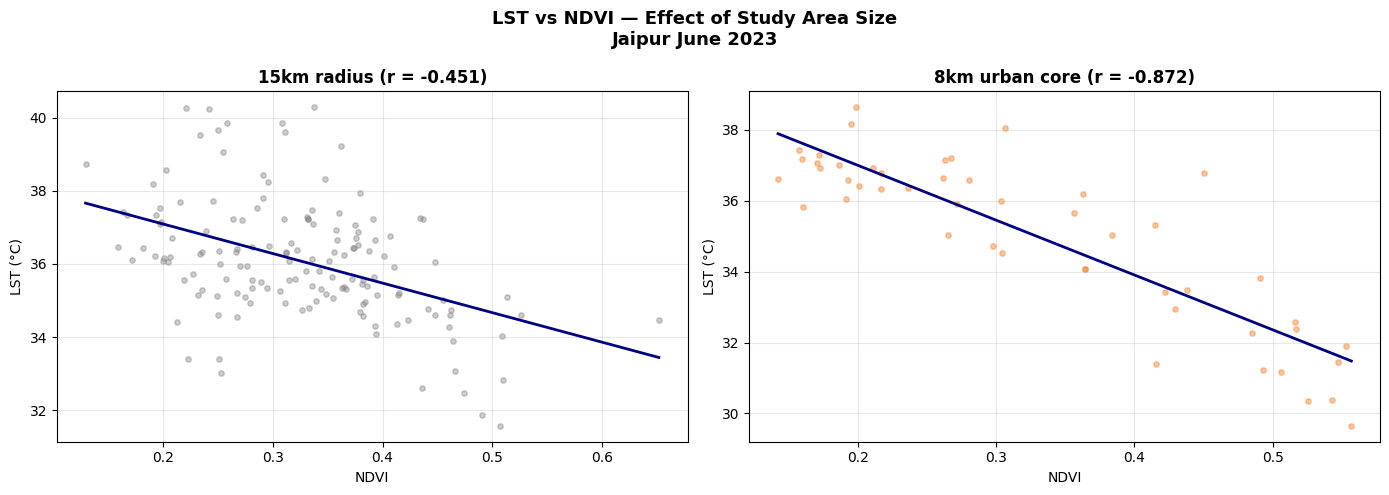

In [6]:
# Focus on urban core only — 8km radius
jaipur_urban = ee.Geometry.Point([75.8235, 26.9124]).buffer(8000)

# Resample from urban core
combined_urban = lst_jaipur.addBands(ndvi).clip(jaipur_urban)

samples_urban = combined_urban.sample(
    region=jaipur_urban,
    scale=100,
    numPixels=500,
    seed=42
)

sample_list_urban = samples_urban.getInfo()['features']
print(f"Urban pixels sampled: {len(sample_list_urban)}")

lst_u  = [f['properties']['LST_Celsius'] for f in sample_list_urban]
ndvi_u = [f['properties']['NDVI'] for f in sample_list_urban]

df_urban = pd.DataFrame({'lst': lst_u, 'ndvi': ndvi_u})
df_urban = df_urban[
    (df_urban['lst'] > 25) &
    (df_urban['lst'] < 55) &
    (df_urban['ndvi'] > -0.1) &
    (df_urban['ndvi'] < 0.8)
]

corr_urban = df_urban['lst'].corr(df_urban['ndvi'])
print(f"Urban core correlation: {corr_urban:.3f}")
print(f"LST range: {df_urban['lst'].min():.1f} — {df_urban['lst'].max():.1f}°C")
print(f"NDVI range: {df_urban['ndvi'].min():.3f} — {df_urban['ndvi'].max():.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_real['ndvi'], df_real['lst'],
                alpha=0.4, s=15, color='gray')
z = np.polyfit(df_real['ndvi'], df_real['lst'], 1)
p = np.poly1d(z)
x = np.linspace(df_real['ndvi'].min(), df_real['ndvi'].max(), 100)
axes[0].plot(x, p(x), 'navy', linewidth=2)
axes[0].set_title(f"15km radius (r = {corr:.3f})", fontweight='bold')
axes[0].set_xlabel("NDVI")
axes[0].set_ylabel("LST (°C)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_urban['ndvi'], df_urban['lst'],
                alpha=0.4, s=15, color='#F97316')
z2 = np.polyfit(df_urban['ndvi'], df_urban['lst'], 1)
p2 = np.poly1d(z2)
x2 = np.linspace(df_urban['ndvi'].min(), df_urban['ndvi'].max(), 100)
axes[1].plot(x2, p2(x2), 'navy', linewidth=2)
axes[1].set_title(f"8km urban core (r = {corr_urban:.3f})", fontweight='bold')
axes[1].set_xlabel("NDVI")
axes[1].set_ylabel("LST (°C)")
axes[1].grid(True, alpha=0.3)

fig.suptitle("LST vs NDVI — Effect of Study Area Size\nJaipur June 2023",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()